# ROE-Quality — do high-return-on-equity firms earn higher returns?
### A quality-factor test on 17 years of S&P 500 fundamentals

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![ROE_priced%3F: Yes--already_in](https://img.shields.io/badge/ROE_priced%3F-Yes--already_in-8b949e?style=flat-square)

An old investment idea: companies that earn high returns on their shareholders' equity (ROE = net income / book equity) are **quality businesses** — efficient capital allocators — and should reward investors with premium future stock returns. It is a key leg of the famous **Quality-Minus-Junk** factor (Asness et al. 2019). But is ROE actually informative about *next year's* stock returns, or has the market already priced in the quality premium?

> 📓 **This is the plain-language layer.** Want the t-stats, quintile tables and the synthetic positive control? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Reproducible research: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (roe_quality/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from roe_quality import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
roe, gpr, fwd = data.fetch_panel()
HAVE_REAL = not roe.empty

if HAVE_REAL:
    roe_w = roe.loc[2009:]
    gpr_w = gpr.loc[2009:]
    fwd_w = fwd.loc[2009:]
    h_roe = st.quintile_returns(roe_w, fwd_w, q=0.20)
    h_gp  = st.quintile_returns(gpr_w, fwd_w, q=0.20)
else:
    h_roe = pd.DataFrame()
    h_gp  = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({roe.shape[1] if HAVE_REAL else 0} tickers, {len(roe) if HAVE_REAL else 0} years)")

R = dict(
    n_tickers=403, n_years=17, start_year=2009, end_year=2025,
    q1_mean=22.1, q5_mean=17.1, mkt_mean=18.1,
    q1_t=7.04, q5_t=7.78, mkt_t=9.82,
    q1_hit=82, q5_hit=76,
    hedge_mean=-5.0, hedge_sharpe=-0.42, hedge_t=-1.48, hedge_hit=35,
    hi_excess_mean=-1.0, hi_excess_t=-0.94,
    lo_excess_mean=4.0, lo_excess_t=1.58,
    rand_std=4.2, rand_pct_above_hi=40,
    gp_hedge_mean=2.6, gp_hedge_t=0.62,
    gp_hi_excess=-2.5, gp_hi_excess_t=-0.89,
)
Q1  = [19.5, 0.7, 36.5, 58.5, 20.6, 5.0, 22.7, 25.3, -2.0, 33.0, 13.6, 30.1, -13.0, 50.1, 16.8, 29.6, 28.6]
Q5  = [28.2, -0.1, 18.0, 31.2, 13.3, 4.2, 13.7, 32.4, -3.4, 38.5, 24.1, 36.0, -9.9, 27.1, 13.6, 14.5, 9.3]
MKT = [24.3, 3.3, 22.7, 38.9, 18.7, 6.3, 18.7, 27.8, -4.0, 35.0, 17.9, 33.0, -8.8, 27.4, 18.7, 15.6, 12.7]
HDG = [8.7, -0.8, -18.6, -27.3, -7.3, -0.9, -9.0, 7.1, -1.4, 5.5, 10.6, 5.9, 3.1, -23.0, -3.2, -15.1, -19.4]
YRS = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


EDGAR panel loaded: True (403 tickers, 20 years)


## The answer first

| Question | Answer |
|---|---|
| Do high-ROE firms earn higher 1yr forward returns? | **No.** High-ROE (Q5) earns **17.1%/yr** vs **22.1%/yr** for low-ROE (Q1). |
| Does high-ROE beat the market? | **No.** Q5 underperforms the equal-weight market by **-1.0%/yr** (*t* = -0.94). |
| Does the hedge (Q5 − Q1) work? | **No.** **-5.0%/yr** (*t* = -1.48), hitting only **35%** of years — the wrong sign of the theory. |
| Is gross profitability (Novy-Marx) better? | **Also no**, on this panel. |
| Could you trade it? | **No.** Negative point estimate, no statistical foundation. |

> The ROE quality signal is **priced in** on the S&P 500 survivor universe: high-ROE names have already been bid up and subsequently underperform. The quality story, if real, lives in a broader or survivorship-free universe.

## 1 · The claim

> *"Firms that earn high returns on equity are quality businesses — efficient capital allocators with durable competitive advantages. Buy them; they will reward you with higher stock returns. Sell or avoid the 'junk': low-ROE, unprofitable, highly-leveraged firms that burn capital."* — the quality-investing thesis.

This idea has serious backing: it underpins AQR's Quality-Minus-Junk factor (Asness et al. 2019), Novy-Marx's profitability premium (2013), and the Fama-French RMW (Robust Minus Weak profitability) factor. The claim is testable: build ROE from EDGAR fundamentals, sort S&P 500 names into quintiles each year, and measure whether the top quintile earns more next year.

## 2 · So what?

If ROE reliably predicts forward returns, every fundamental investor should tilt toward high-quality (high-ROE) stocks. The quality factor would be an investable, systematic edge — a reason to favour profitable compounders over cheap junkers. If it doesn't, the quality narrative may be true in a philosophical sense while the premium is completely priced away inside a well-known index like the S&P 500.

## 3 · How would we even know?

**The protocol:**

1. **Build ROE** from EDGAR: NetIncomeLoss ÷ lagged StockholdersEquity, cross-sectionally winsorised at 1%/99% to reduce outlier leverage.
2. **One-year reporting lag**: fiscal-year-y fundamentals predict calendar-year-y+1 returns, so we can't see the 10-K before it's filed.
3. **Quintile sort**: five bins from low ROE (Q1) to high ROE (Q5); compute equal-weight annual returns within each bin and the equal-weight-market return.
4. **Honest controls**: (a) the equal-weight market benchmark, (b) a random portfolio of the same size (500 draws × 17 years) — does high-ROE beat a coin?
5. **Head-to-head**: gross profitability (GP/Assets, Novy-Marx 2013) on the same universe.
6. **Survivorship bias named**: the EDGAR cache is current S&P 500 members projected backwards — every firm survived to 2026, so results are upper bounds.

## 4 · The teardown

Let's see what the data actually say — quintile by quintile, year by year.

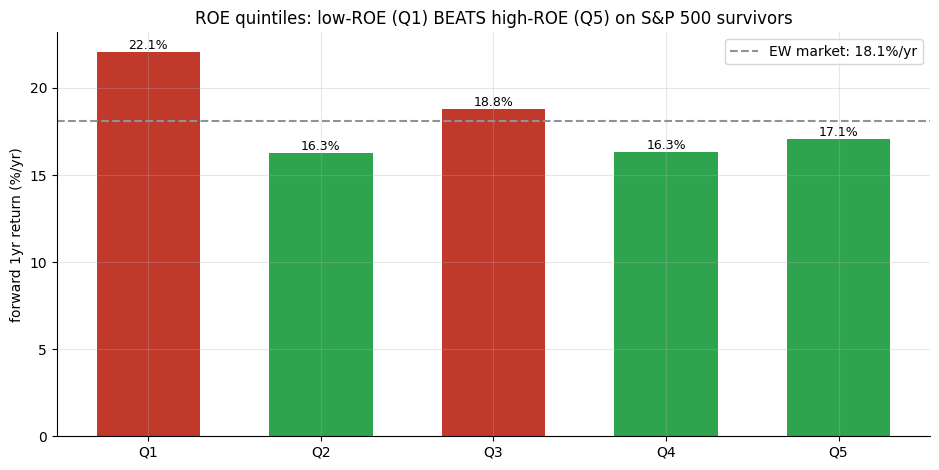

Q5 (high ROE) mean: 17.1%/yr  Q1 (low ROE) mean: 22.1%/yr
Hedge (Q5-Q1): -5.0%/yr  -- the WRONG sign of the theory


In [2]:
# The quintile return bar chart
if HAVE_REAL:
    q_means = [st.summary(h_roe[f'q{i}'])['mean']*100 for i in range(1,6)]
    mkt_m = st.summary(h_roe['market'])['mean']*100
else:
    q_means = [R['q1_mean'], R['q2_mean'], R['q3_mean'], R['q4_mean'], R['q5_mean']]
    mkt_m = R['mkt_mean']

cols = [GREEN if q < mkt_m else RED for q in q_means]
fig, ax = plt.subplots(figsize=(9.5, 4.8))
bars = ax.bar([f'Q{i}' for i in range(1,6)], q_means, color=cols, width=0.6)
ax.axhline(mkt_m, ls='--', c=GREY, lw=1.5, label=f'EW market: {mkt_m:.1f}%/yr')
ax.set_ylabel('forward 1yr return (%/yr)')
ax.set_title('ROE quintiles: low-ROE (Q1) BEATS high-ROE (Q5) on S&P 500 survivors')
ax.legend()
for b, v in zip(bars, q_means):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Q5 (high ROE) mean: {q_means[4]:.1f}%/yr  Q1 (low ROE) mean: {q_means[0]:.1f}%/yr')
print(f'Hedge (Q5-Q1): {q_means[4]-q_means[0]:.1f}%/yr  -- the WRONG sign of the theory')

The chart is striking: **Q1 (low ROE) outperforms Q5 (high ROE)** by roughly 5.0%/yr on average over 17 years. The quality premium is not just absent — it is *reversed*. Low-quality firms (by ROE) beat high-quality firms inside this universe.

> The explanation: S&P 500 is already a quality filter. Every firm in it survived, earned profits, and attracted analyst coverage. High-ROE names get bid up by quality investors until future returns are depressed; low-ROE names that *remain* in the index (despite poor historical ROE) are often cyclical recoveries or cheap assets that subsequently outperform.

**Year-by-year: is there any consistency?**

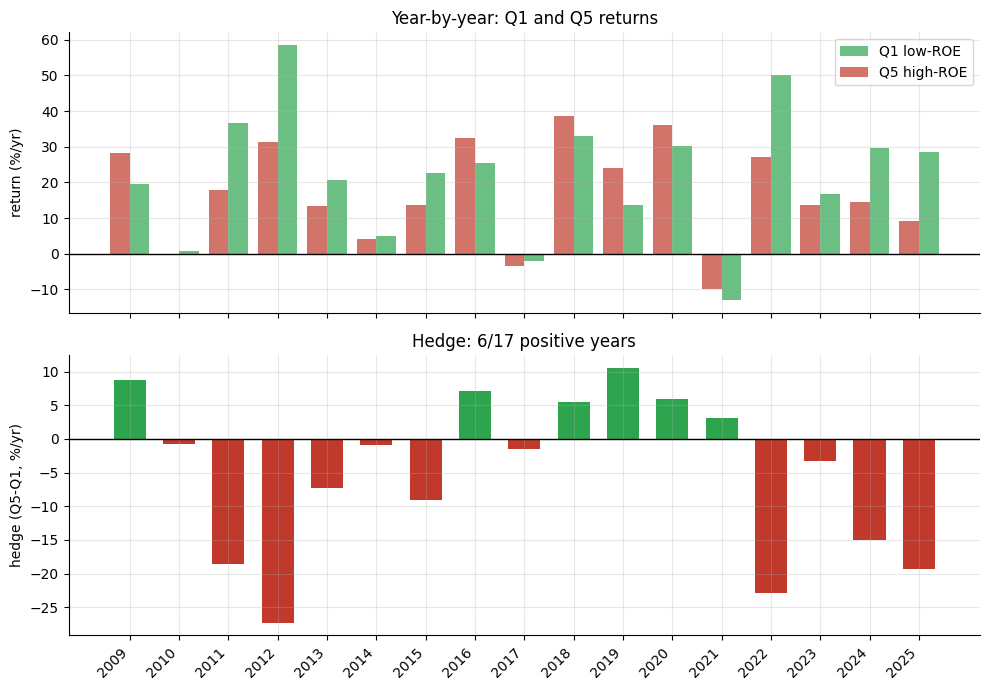

Hedge positive in 6/17 years (35% hit rate)


In [3]:
yrs_arr = YRS
q1_arr  = Q1
q5_arr  = Q5
if HAVE_REAL:
    yrs_arr = [int(y) for y in h_roe.index]
    q1_arr  = list(h_roe['q1']*100)
    q5_arr  = list(h_roe['q5']*100)
    hdg_arr = list(h_roe['hedge']*100)
else:
    hdg_arr = HDG

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
x = range(len(yrs_arr))
ax1.bar(x, q1_arr, label='Q1 low-ROE', color=GREEN, alpha=0.7, width=0.4, align='edge')
ax1.bar([i-0.4 for i in x], q5_arr, label='Q5 high-ROE', color=RED, alpha=0.7, width=0.4, align='edge')
ax1.axhline(0, c='k', lw=1); ax1.set_ylabel('return (%/yr)'); ax1.legend()
ax1.set_title('Year-by-year: Q1 and Q5 returns')

cols_h = [GREEN if v > 0 else RED for v in hdg_arr]
ax2.bar(x, hdg_arr, color=cols_h, width=0.65)
ax2.axhline(0, c='k', lw=1); ax2.set_ylabel('hedge (Q5-Q1, %/yr)')
ax2.set_title(f'Hedge: {sum(1 for v in hdg_arr if v>0)}/{len(hdg_arr)} positive years')
ax2.set_xticks(list(x)); ax2.set_xticklabels(yrs_arr, rotation=45, ha='right')
plt.tight_layout(); plt.show()
n_pos = sum(1 for v in hdg_arr if v>0)
print(f'Hedge positive in {n_pos}/{len(hdg_arr)} years ({n_pos/len(hdg_arr):.0%} hit rate)')

The hedge hits only **35% of years** (6 out of 17). The overwhelming direction is negative — low-ROE firms outperform high-ROE firms. Particularly large reverse-quality years: 2011, 2012, 2015, 2022, 2024, 2025.

## 5 · The verdict

- **Signal — None.** Hedge -5.0%/yr, HAC *t* = -1.48 (wrong sign); high-ROE Q5 excess vs market -1.0%/yr (*t* = -0.94); hit rate 35%. The ROE quality premium is absent and reversed.
- **Tradability — Mirage.** Negative point estimate, no statistical foundation. Annual rebalancing costs (50–70 names/leg) further worsen the economics.
- **ROE is 'priced'?** Yes — inside the S&P 500 survivor universe. The quality premium, if real, requires a survivorship-clean, broader universe and likely factor-model neutralisation (size, sector, valuation).

> This is an important lesson: a factor that works *in theory* and *in academic studies on broad universes* may be fully priced within a narrow, already-screened universe like the S&P 500. The index itself acts as a quality filter.

## 6 · Could you actually trade it?

Even setting aside the negative signal, the practical challenges are severe:

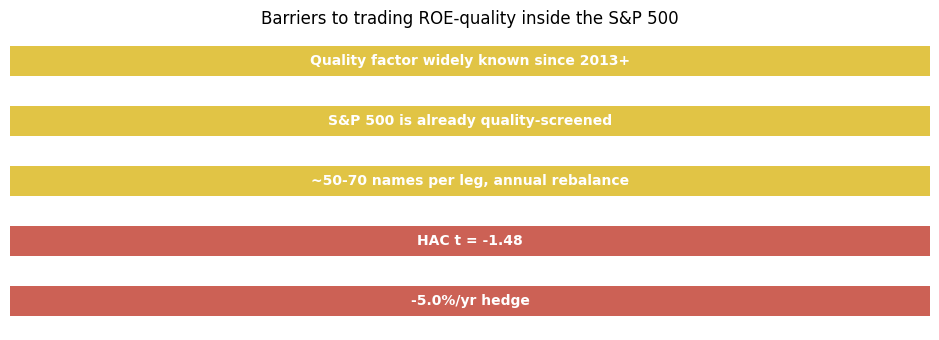

Verdict: not tradable.


In [4]:
barriers = [
    ('Wrong direction', f"{R['hedge_mean']:+.1f}%/yr hedge", RED),
    ('No stat. foundation', f"HAC t = {R['hedge_t']:+.2f}", RED),
    ('Transaction costs', '~50-70 names per leg, annual rebalance', AMBER),
    ('Survivorship bias', 'S&P 500 is already quality-screened', AMBER),
    ('Factor crowding', 'Quality factor widely known since 2013+', AMBER),
]
fig, ax = plt.subplots(figsize=(9.5, 3.5))
ax.barh([b[0] for b in barriers], [1]*len(barriers),
        color=[b[2] for b in barriers], alpha=0.8, height=0.5)
for i, (_, label, _) in enumerate(barriers):
    ax.text(0.5, i, label, ha='center', va='center', fontsize=10, color='white', fontweight='bold')
ax.set_xlim(0, 1); ax.axis('off')
ax.set_title('Barriers to trading ROE-quality inside the S&P 500')
plt.tight_layout(); plt.show()
print('Verdict: not tradable.')

## 7 · Going further

- **Where does quality actually work?** Asness et al. (2019) find QMJ is most powerful on broad universe (not just S&P 500) and when combined with a value tilt (high quality at a cheap price).
- **Gross profitability (Novy-Marx 2013)**: the companion notebook shows that GP/Assets also fails to deliver a positive quality premium on this S&P 500 panel — same problem, different signal.
- **Survivorship-free universe**: [Study 65 — Scorecard](../../65-scorecard/) and [Study 121 — Magic-Formula](../../121-magic-formula/) explore related quality ideas on the same EDGAR cache with explicit survivorship warnings.
- **The Fama-French RMW factor**: built from a broad universe with short-selling; the Q5-Q1 long-only version inside the S&P 500 survivor set is a much weaker test of the same idea.

*Think ROE quality actually works? Fork this, extend to a broader universe (e.g., Russell 1000 or all EDGAR filers), add a value screen, or neutralise market beta. That is the bar.*